In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/train_data.csv")

df.head()

,train_id,train_name,source,destination,distance_km,scheduled_departure,weather,temperature,rainfall,station_delay,previous_delay,delay_minutes
0,TRN1001,Jan Shatabdi,Guntur,Tirupati,350,10:00,Rain,38,12.48,6.12,15.07,28.32
1,TRN1002,Garib Rath,Hyderabad,Vijayawada,539,21:00,Clear,34,41.98,2.90,4.28,15.53
2,TRN1003,Shatabdi Express,Guntur,Tirupati,646,19:00,Cloudy,20,68.80,2.90,21.39,17.81
3,TRN1004,Krishna Express,Secunderabad,Nizamabad,419,14:00,Cloudy,29,39.61,9.48,13.76,16.29
4,TRN1005,Rajdhani Express,Nellore,Chennai,469,21:00,Cloudy,39,2.51,4.29,16.41,26.34


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 5000
Number of Columns: 12


In [4]:
df.columns.tolist()

['train_id',
 'train_name',
 'source',
 'destination',
 'distance_km',
 'scheduled_departure',
 'weather',
 'temperature',
 'rainfall',
 'station_delay',
 'previous_delay',
 'delay_minutes']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   train_id             5000 non-null   str    
 1   train_name           5000 non-null   str    
 2   source               5000 non-null   str    
 3   destination          5000 non-null   str    
 4   distance_km          5000 non-null   int64  
 5   scheduled_departure  5000 non-null   str    
 6   weather              5000 non-null   str    
 7   temperature          5000 non-null   int64  
 8   rainfall             5000 non-null   float64
 9   station_delay        5000 non-null   float64
 10  previous_delay       5000 non-null   float64
 11  delay_minutes        5000 non-null   float64
dtypes: float64(4), int64(2), str(6)
memory usage: 710.5 KB


In [6]:
df.describe()

,distance_km,temperature,rainfall,station_delay,previous_delay,delay_minutes
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,388.976600,29.552800,39.973776,5.188808,8.523648,18.520758
std,179.401661,6.880922,23.032511,3.633915,6.257838,8.364112
min,80.000000,18.000000,0.010000,0.000000,0.000000,0.000000
25%,235.000000,24.000000,20.207500,2.307500,3.410000,12.607500
50%,386.000000,29.000000,40.055000,5.010000,8.115000,18.070000
75%,546.250000,36.000000,59.330000,7.690000,12.742500,23.957500
max,699.000000,41.000000,79.950000,18.640000,35.320000,50.210000


In [7]:
missing_values = df.isnull().sum()

print(missing_values)

train_id               0
train_name             0
source                 0
destination            0
distance_km            0
scheduled_departure    0
weather                0
temperature            0
rainfall               0
station_delay          0
previous_delay         0
delay_minutes          0
dtype: int64


In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [9]:
print(df["delay_minutes"].describe())

count    5000.000000
mean       18.520758
std         8.364112
min         0.000000
25%        12.607500
50%        18.070000
75%        23.957500
max        50.210000
Name: delay_minutes, dtype: float64


In [10]:
average_delay = df["delay_minutes"].mean()

print("Average Train Delay:", round(average_delay, 2), "minutes")

Average Train Delay: 18.52 minutes


In [11]:
max_delay = df["delay_minutes"].max()

print("Maximum Train Delay:", round(max_delay, 2), "minutes")

Maximum Train Delay: 50.21 minutes


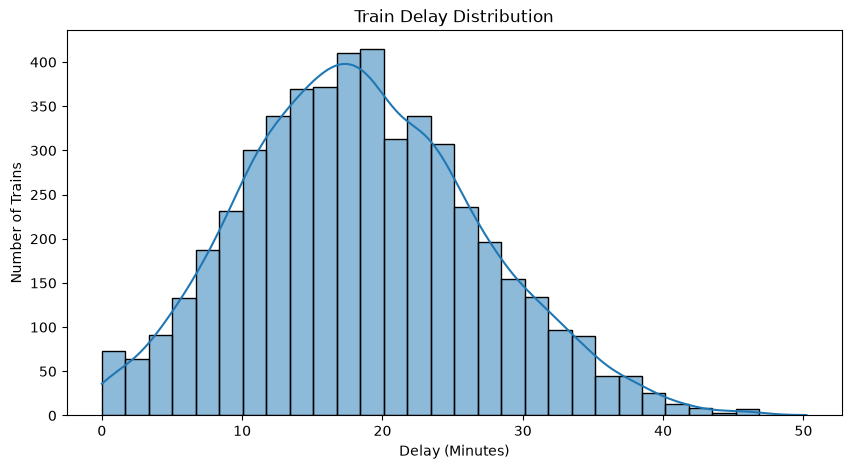

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["delay_minutes"],
    bins=30,
    kde=True
)

plt.title("Train Delay Distribution")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Number of Trains")

plt.show()

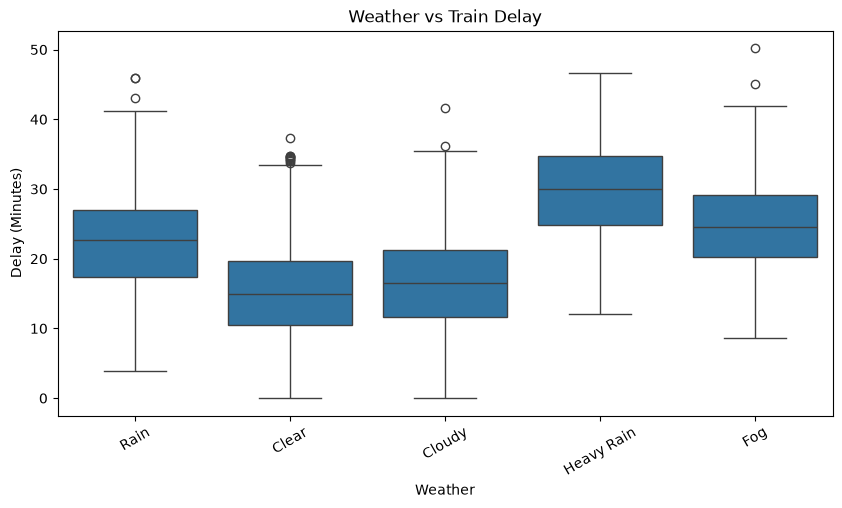

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="weather",
    y="delay_minutes"
)

plt.title("Weather vs Train Delay")
plt.xlabel("Weather")
plt.ylabel("Delay (Minutes)")

plt.xticks(rotation=30)

plt.show()

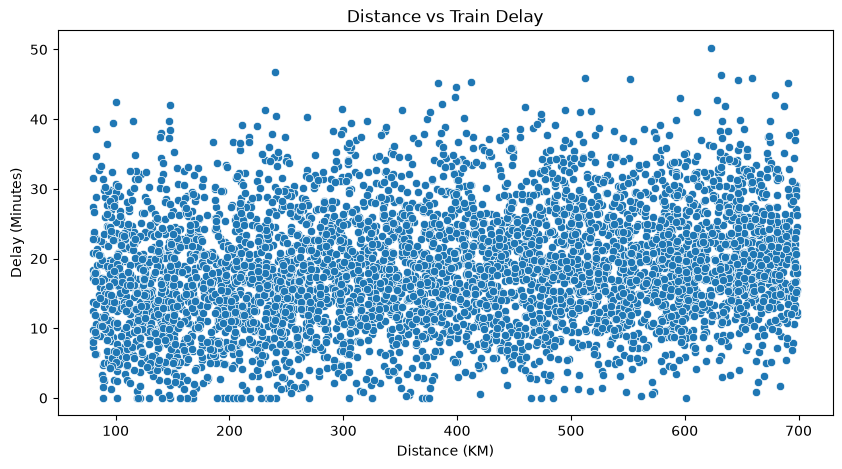

In [14]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="delay_minutes"
)

plt.title("Distance vs Train Delay")
plt.xlabel("Distance (KM)")
plt.ylabel("Delay (Minutes)")

plt.show()

In [15]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

correlation

,distance_km,temperature,rainfall,station_delay,previous_delay,delay_minutes
distance_km,1.000000,-0.019820,0.005635,-0.018034,-0.011799,0.195423
temperature,-0.019820,1.000000,-0.019882,0.006774,0.003760,-0.001133
rainfall,0.005635,-0.019882,1.000000,-0.005787,-0.005289,0.010423
station_delay,-0.018034,0.006774,-0.005787,1.000000,-0.005297,0.400394
previous_delay,-0.011799,0.003760,-0.005289,-0.005297,1.000000,0.297332
delay_minutes,0.195423,-0.001133,0.010423,0.400394,0.297332,1.000000


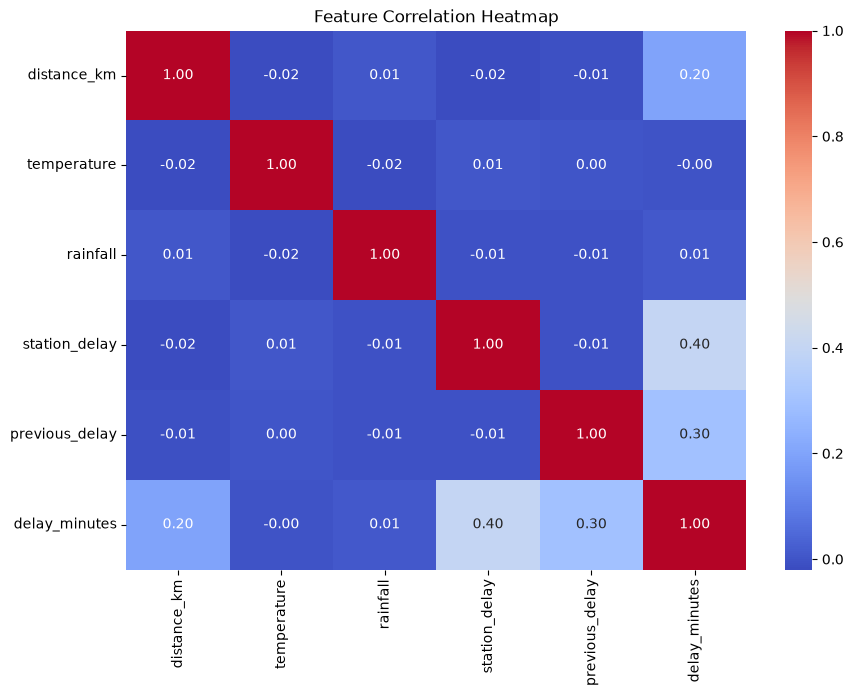

In [16]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()